In [2]:
import pandas as pd

df = pd.read_parquet(
    "/mnt/c/Users/rabia/Desktop/workintech/Hourly_Energy_Consumption_MLOps_Project/data/processed/AEP_hourly_processed.parquet"
)

prophet_df = df[["Datetime", "AEP_MW"]].rename(columns={
    "Datetime": "ds",
    "AEP_MW": "y"
})

prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])


In [3]:
#time-split
split = int(len(prophet_df) * 0.8)

train = prophet_df.iloc[:split]
test  = prophet_df.iloc[split:]

In [5]:
# prophet model
from prophet import Prophet

model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

model.fit(train)


/mnt/c/Users/rabia/Desktop/workintech/Hourly_Energy_Consumption_MLOps_Project/general/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
08:36:05 - cmdstanpy - INFO - Chain [1] start processing
08:37:16 - cmdstanpy - INFO - Chain [1] done processing


In [6]:
# forecast
future = model.make_future_dataframe(
    periods=len(test),
    freq="H"
)

forecast = model.predict(future)

/mnt/c/Users/rabia/Desktop/workintech/Hourly_Energy_Consumption_MLOps_Project/general/lib/python3.12/site-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


In [7]:
# Test Tahminlerini Çek
pred = forecast.iloc[-len(test):]["yhat"].values
y_true = test["y"].values


In [9]:
# Metrik
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_true, pred)
rmse = np.sqrt(mean_squared_error(y_true, pred))

print("Prophet MAE:", mae)
print("Prophet RMSE:", rmse)


Prophet MAE: 1394.9461792767927
Prophet RMSE: 1794.282858182013


In [ ]:
# MLflow Log
import mlflow

mlflow.set_experiment("energy_prophet")

with mlflow.start_run(run_name="prophet_AEP"):
    mlflow.log_param("model", "Prophet")
    mlflow.log_metric("MAE", float(mae))
    mlflow.log_metric("RMSE", float(rmse))


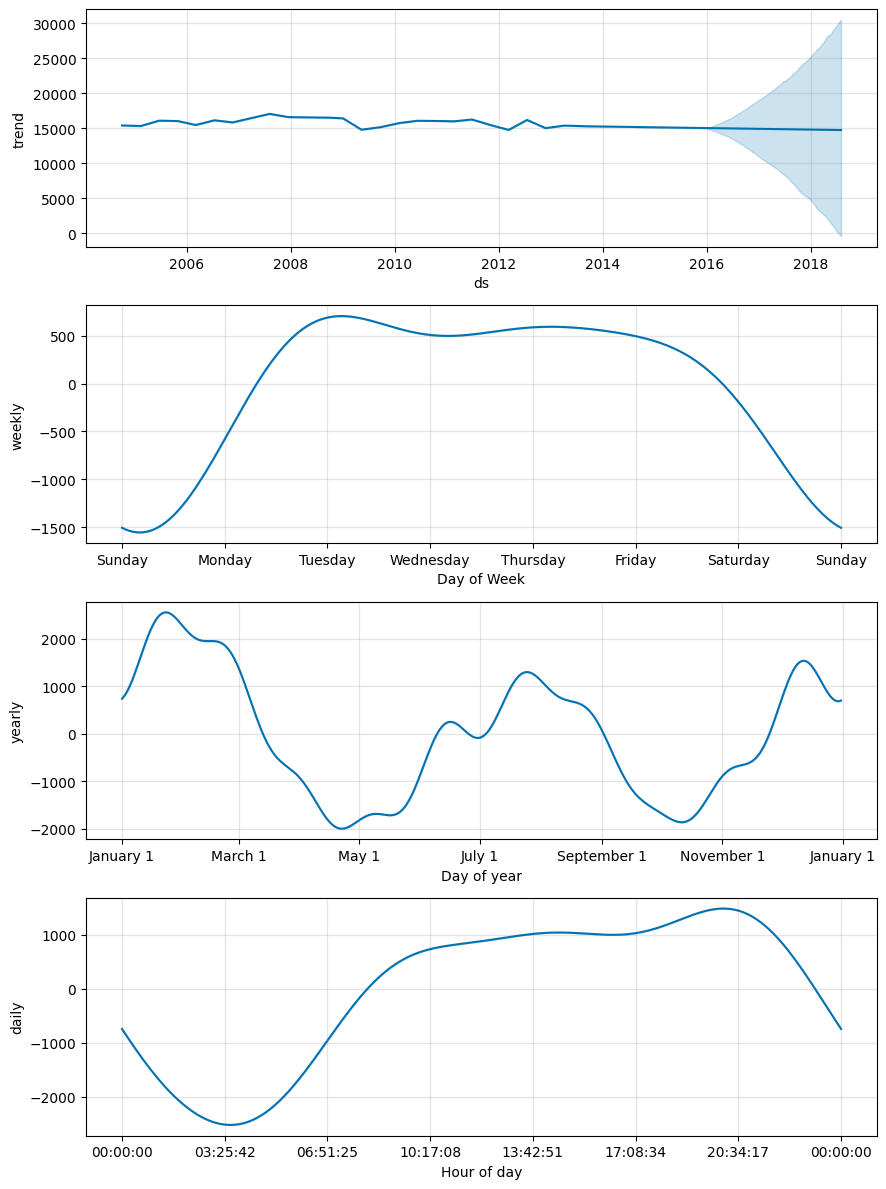

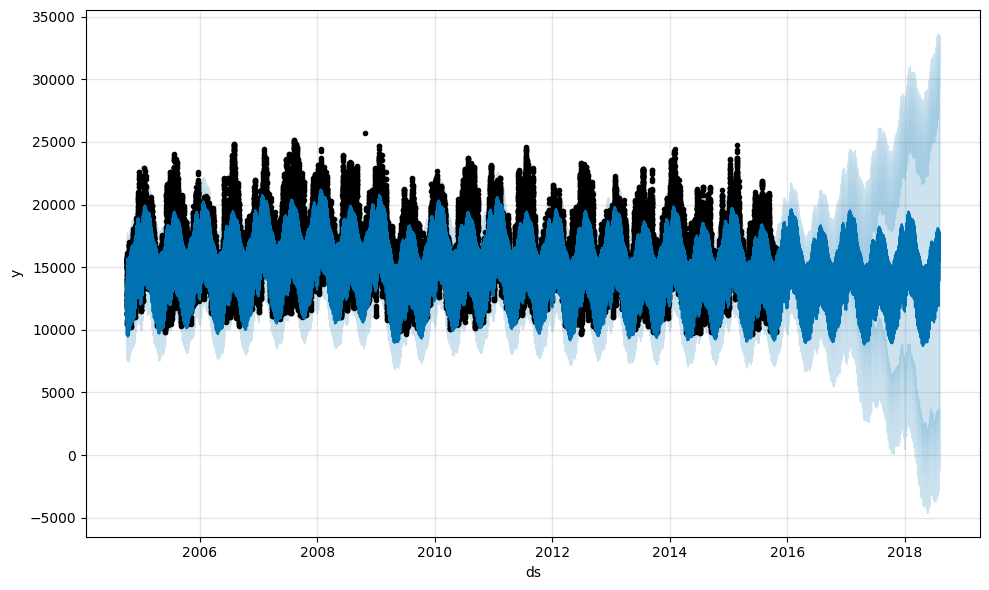

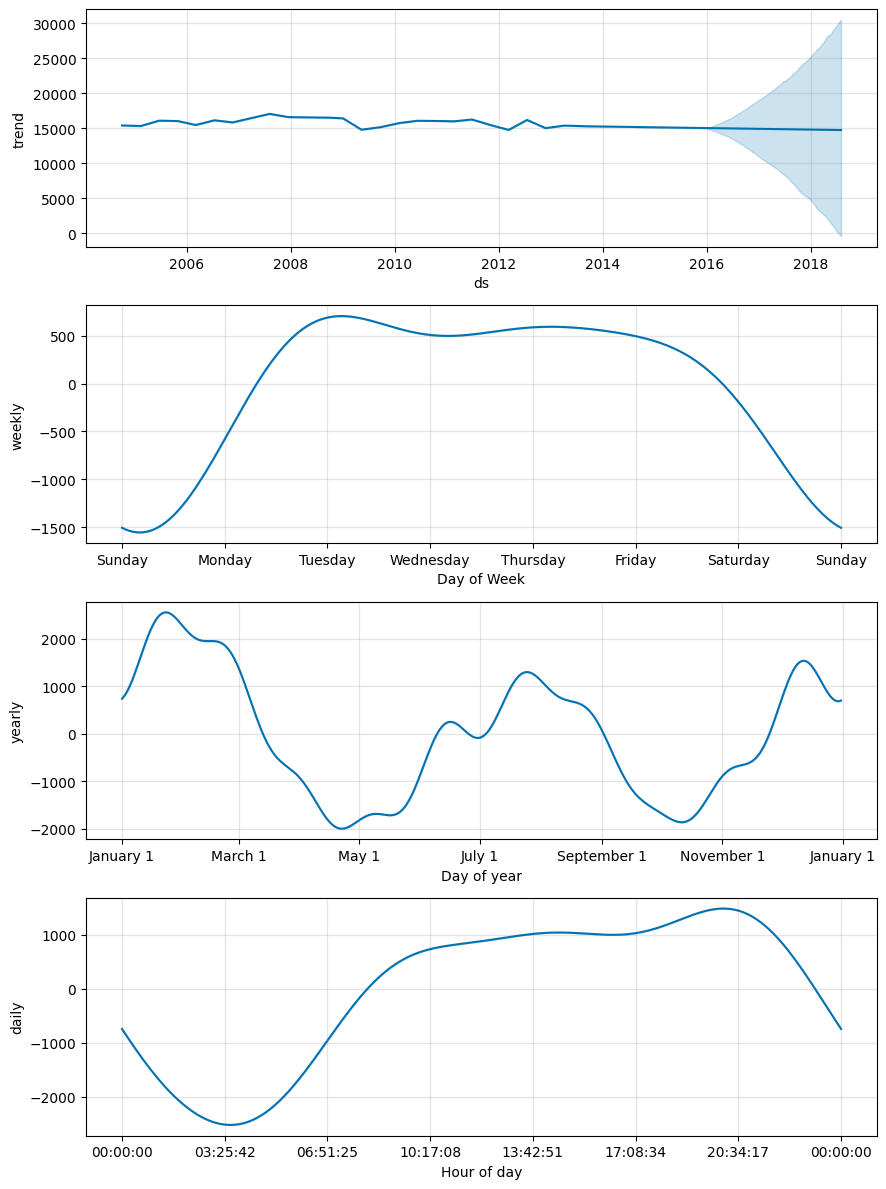

In [10]:
model.plot(forecast)
model.plot_components(forecast)